In [24]:
import pandas as pd
from madrid_rental.database.connection import get_engine
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
engine = get_engine()

query = """
    SELECT a.precio, a.superficie, a.habitaciones, a.banos, b.nombre AS barrio
    FROM anuncios a
    JOIN barrios b ON a.barrio_id = b.id
"""

df = pd.read_sql(query, engine)
df.head()

,precio,superficie,habitaciones,banos,barrio
0,2317.06,131.0,3,1,Arganzuela
1,517.98,40.0,2,1,Usera
2,601.34,55.0,1,1,Carabanchel
3,734.11,60.0,2,3,Vallecas
4,1365.49,80.0,2,3,Arganzuela


In [4]:
df.shape

(1000, 5)

In [5]:
df.describe()

,precio,superficie,habitaciones,banos
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,1972.697110,120.230000,2.508000,1.972000
std,926.232611,47.549596,1.129253,0.809859
min,418.690000,40.000000,1.000000,1.000000
25%,1218.977500,76.000000,1.000000,1.000000
50%,1891.535000,121.000000,3.000000,2.000000
75%,2620.290000,163.000000,4.000000,3.000000
max,5039.240000,200.000000,4.000000,3.000000


In [6]:
df['precio_m2'] = df['precio']/df['superficie']
df.head()

,precio,superficie,habitaciones,banos,barrio,precio_m2
0,2317.06,131.0,3,1,Arganzuela,17.687481
1,517.98,40.0,2,1,Usera,12.949500
2,601.34,55.0,1,1,Carabanchel,10.933455
3,734.11,60.0,2,3,Vallecas,12.235167
4,1365.49,80.0,2,3,Arganzuela,17.068625


In [8]:
precio_por_barrio = df.groupby("barrio")["precio_m2"].mean().sort_values(ascending=False)
precio_por_barrio

barrio
Salamanca      22.028870
Chamberí       19.970901
Centro         19.030758
Retiro         18.229032
Chamartín      17.225323
Arganzuela     16.052917
Tetuán         15.137871
Usera          11.950568
Carabanchel    11.913851
Vallecas       11.057991
Name: precio_m2, dtype: float64

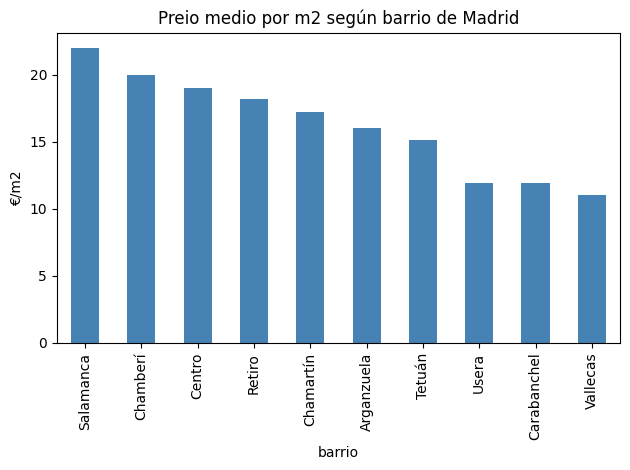

In [11]:
precio_por_barrio.plot(kind='bar', color='steelblue')
plt.title("Preio medio por m2 según barrio de Madrid")
plt.ylabel("€/m2")
plt.tight_layout()
plt.show()

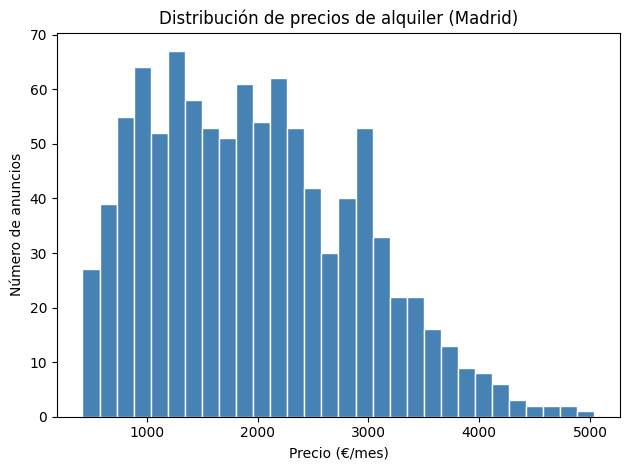

In [21]:
df["precio"].plot(kind="hist", bins=30, color="steelblue", edgecolor="white")
plt.title("Distribución de precios de alquiler (Madrid)")
plt.xlabel("Precio (€/mes)")
plt.ylabel("Número de anuncios")
plt.tight_layout()
plt.show()

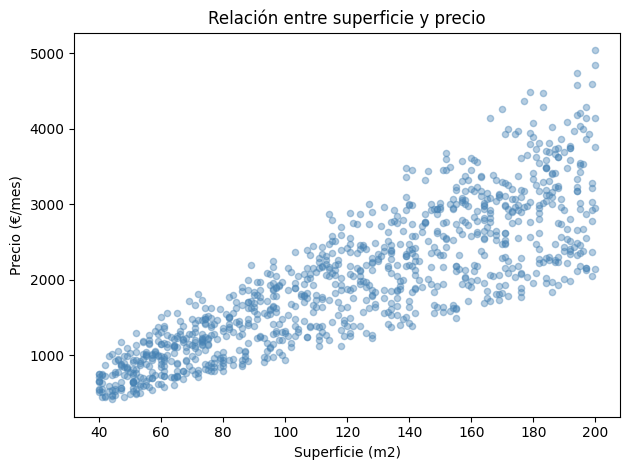

In [22]:
df.plot(kind="scatter", x="superficie", y="precio", alpha=0.4, color="steelblue")
plt.title("Relación entre superficie y precio")
plt.xlabel("Superficie (m2)")
plt.ylabel("Precio (€/mes)")
plt.tight_layout()
plt.show()

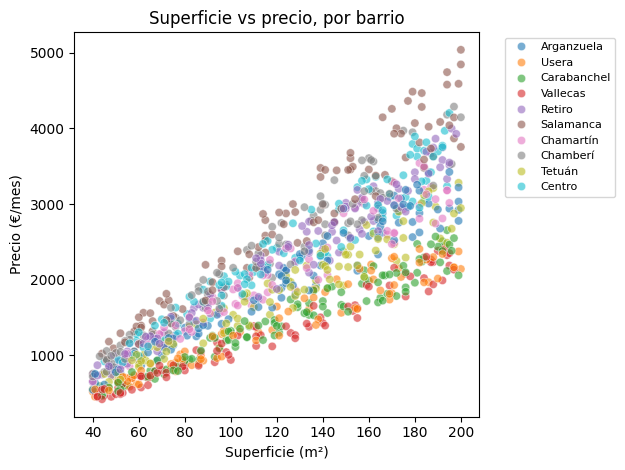

In [ ]:
sns.scatterplot(data=df, x="superficie", y="precio", hue="barrio", alpha=0.6)
plt.title("Superficie vs precio, por barrio")
plt.xlabel("Superficie (m²)")
plt.ylabel("Precio (€/mes)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

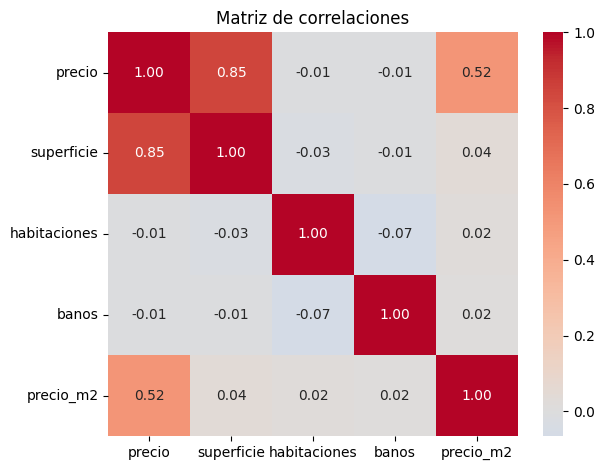

In [26]:
columnas_numericas = ["precio", "superficie", "habitaciones", "banos", "precio_m2"]
correlaciones = df[columnas_numericas].corr()
sns.heatmap(correlaciones, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de correlaciones")
plt.tight_layout()
plt.show()